Ensure that the MCMC can recover known parameter values

In [1]:
import importlib
from escripts import eMCMC
from escripts import eplots
Plotting = eplots.Plotting()
from escripts import estats
import matplotlib.ticker as ticker

/Users/eb35267/Desktop/code/home/escripts/eplots.py:170: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {int(zdat)}$')
/Users/eb35267/Desktop/code/home/escripts/eplots.py:222: SyntaxWarning: invalid escape sequence '\c'
  label = f'{label}, $\chi^2 = {chi2:.0f}$', zorder = 1, color = color, linestyle = ls)
/Users/eb35267/Desktop/code/home/escripts/eplots.py:233: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {int(zdat)}$')


In [46]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [47]:
all_file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']

In [48]:
my_UVLF = eMCMC.UVLF(all_file_names, data_labels)

In [49]:
true_params = [0.66, -0.07, -0.38, -0.01, 12.03, 0.17, -0.95, -0.03, 0.42, 0.04, 0]

In [50]:
mock_phiUV = []
yerr_uppers = []
yerr_lowers = []

for dataarrayz in my_UVLF.data: # Add the log likelihoods together for each redshift. The log likelihood is just a sum over all the points
    # anyways, so this makes sense
    zdat, zerr, xdat, ydat, yerr_upper, yerr_lower, xerr = eMCMC.decompose_data(dataarrayz)
    avg_UV = my_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, true_params)
    mock_phiUV.append(avg_UV)
    # Maintain the same ratio between the error bars & the data
    yerr_uppers.append(avg_UV*yerr_upper/ydat)
    yerr_lowers.append(avg_UV*yerr_lower/ydat)  

<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_32938/2307377991.py:25: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {int(zdat)}$')


Text(0.5, -0.05, '$M_{\\rm{UV}}$ [mag]')

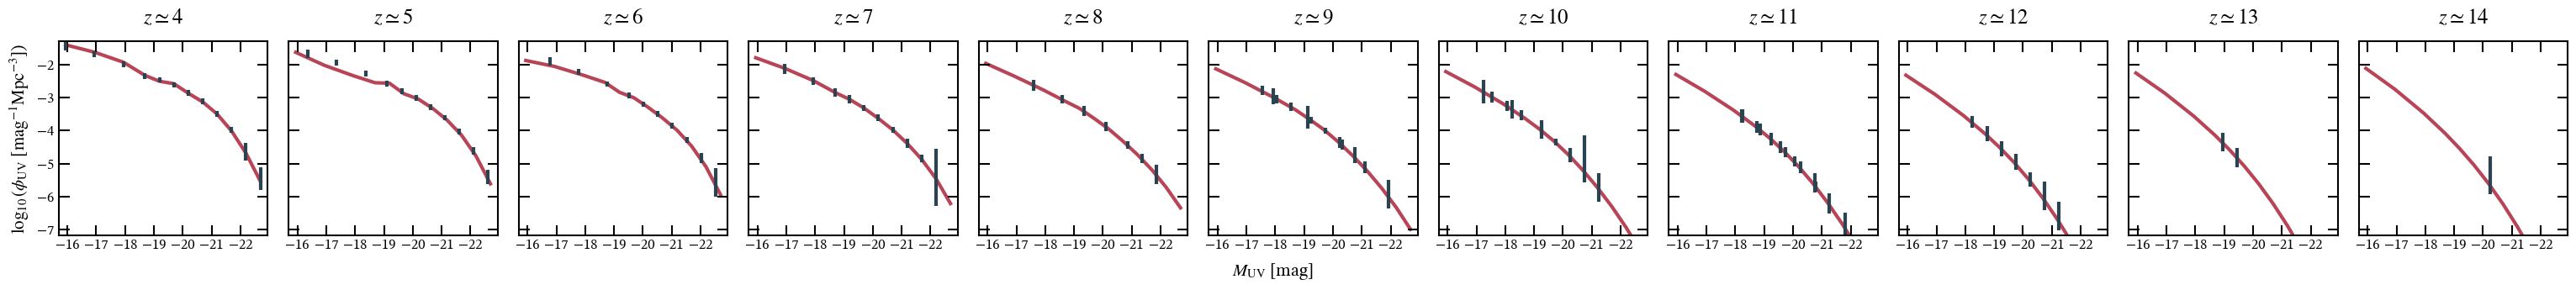

In [51]:
fig, ax = plt.subplots(1, len(mock_phiUV), sharey = True)
fig.set_size_inches(3.5*len(mock_phiUV), 3)
plt.subplots_adjust(wspace = 0.1)

# Set the same y limits for all the plots
ylo, yhi = np.log10(min([min(dat[3]) for dat in my_UVLF.data]))-0.25, np.log10(max([max(dat[3]) for dat in my_UVLF.data]))+0.25

plot_xdat, plot_xerr = my_UVLF.data[0][2], my_UVLF.data[0][5], # Use the lowest redshift MUV centers & bins to calculate the theoretical
                                                            # UVLF (this will make it the smoothest)

for i, (dataarrayz, ydat, yerr_upper, yerr_lower) in enumerate(zip(my_UVLF.data, mock_phiUV, yerr_uppers, yerr_lowers)):
    zdat, zerr, xdat, _, _, _, _ = eMCMC.decompose_data(dataarrayz)

    # Plot best fit:
    ax[i].plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,plot_xdat,plot_xerr,true_params)), zorder = 1, color = Plotting.red, 
               linestyle = '-')
    
    yerr_lower, yerr_upper = estats.calc_log_error(ydat, yerr_lower), estats.calc_log_error(ydat, yerr_upper)
    ax[i].errorbar(xdat, np.log10(ydat), [yerr_lower, yerr_upper], capsize=0, markersize = 9, markeredgecolor = 'none', 
                   markerfacecolor = Plotting.navy, ecolor = Plotting.navy, ls = 'none')
    
    ax[i].invert_xaxis()
    ax[i].set_ylim(ylo, yhi)
    ax[i].set_xlim(np.max(plot_xdat)+0.25, np.min(plot_xdat)-0.25)
    ax[i].set_title(f'$z \simeq {int(zdat)}$')
    ax[i].xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                   # axis labels
ax[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
fig.text(.5, -0.05, r'$M_{\rm{UV}}$ [mag]', ha = 'center')

In [53]:
redshifts = np.concatenate([np.full(len(dat[2]), dat[0]) for dat in my_UVLF.data])
magnitudes = np.concatenate([dat[2] for dat in my_UVLF.data])
dmag = np.concatenate([dat[6] for dat in my_UVLF.data])

In [54]:
eMCMC.save_data(redshifts, magnitudes, dmag, np.concatenate(mock_phiUV), np.concatenate(yerr_uppers), np.concatenate(yerr_lowers), 
                '/Users/eb35267/Desktop/code/home/data/mock_data_no_error.txt')

In [55]:
mock_files = ['/Users/eb35267/Desktop/code/home/data/mock_data_no_error.txt']

In [69]:
mock_UVLF = eMCMC.UVLF(mock_files, ['mock data'])

In [70]:
ICs = mock_UVLF.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [71]:
# Run MCMC
Nsteps=2000
_ = mock_UVLF.sampler.run_mcmc(ICs, Nsteps) 

In [72]:
samples, best_fit, _ = mock_UVLF.get_fit()

In [ ]:
best_fit

[0.61, -0.06, -0.65, -0.08, 12.24, 0.21, -0.91, -0.02, 0.43, 0.04, 0.01]

In [ ]:
true_params

[0.66, -0.07, -0.38, -0.01, 12.03, 0.17, -0.95, -0.03, 0.42, 0.04, 0]

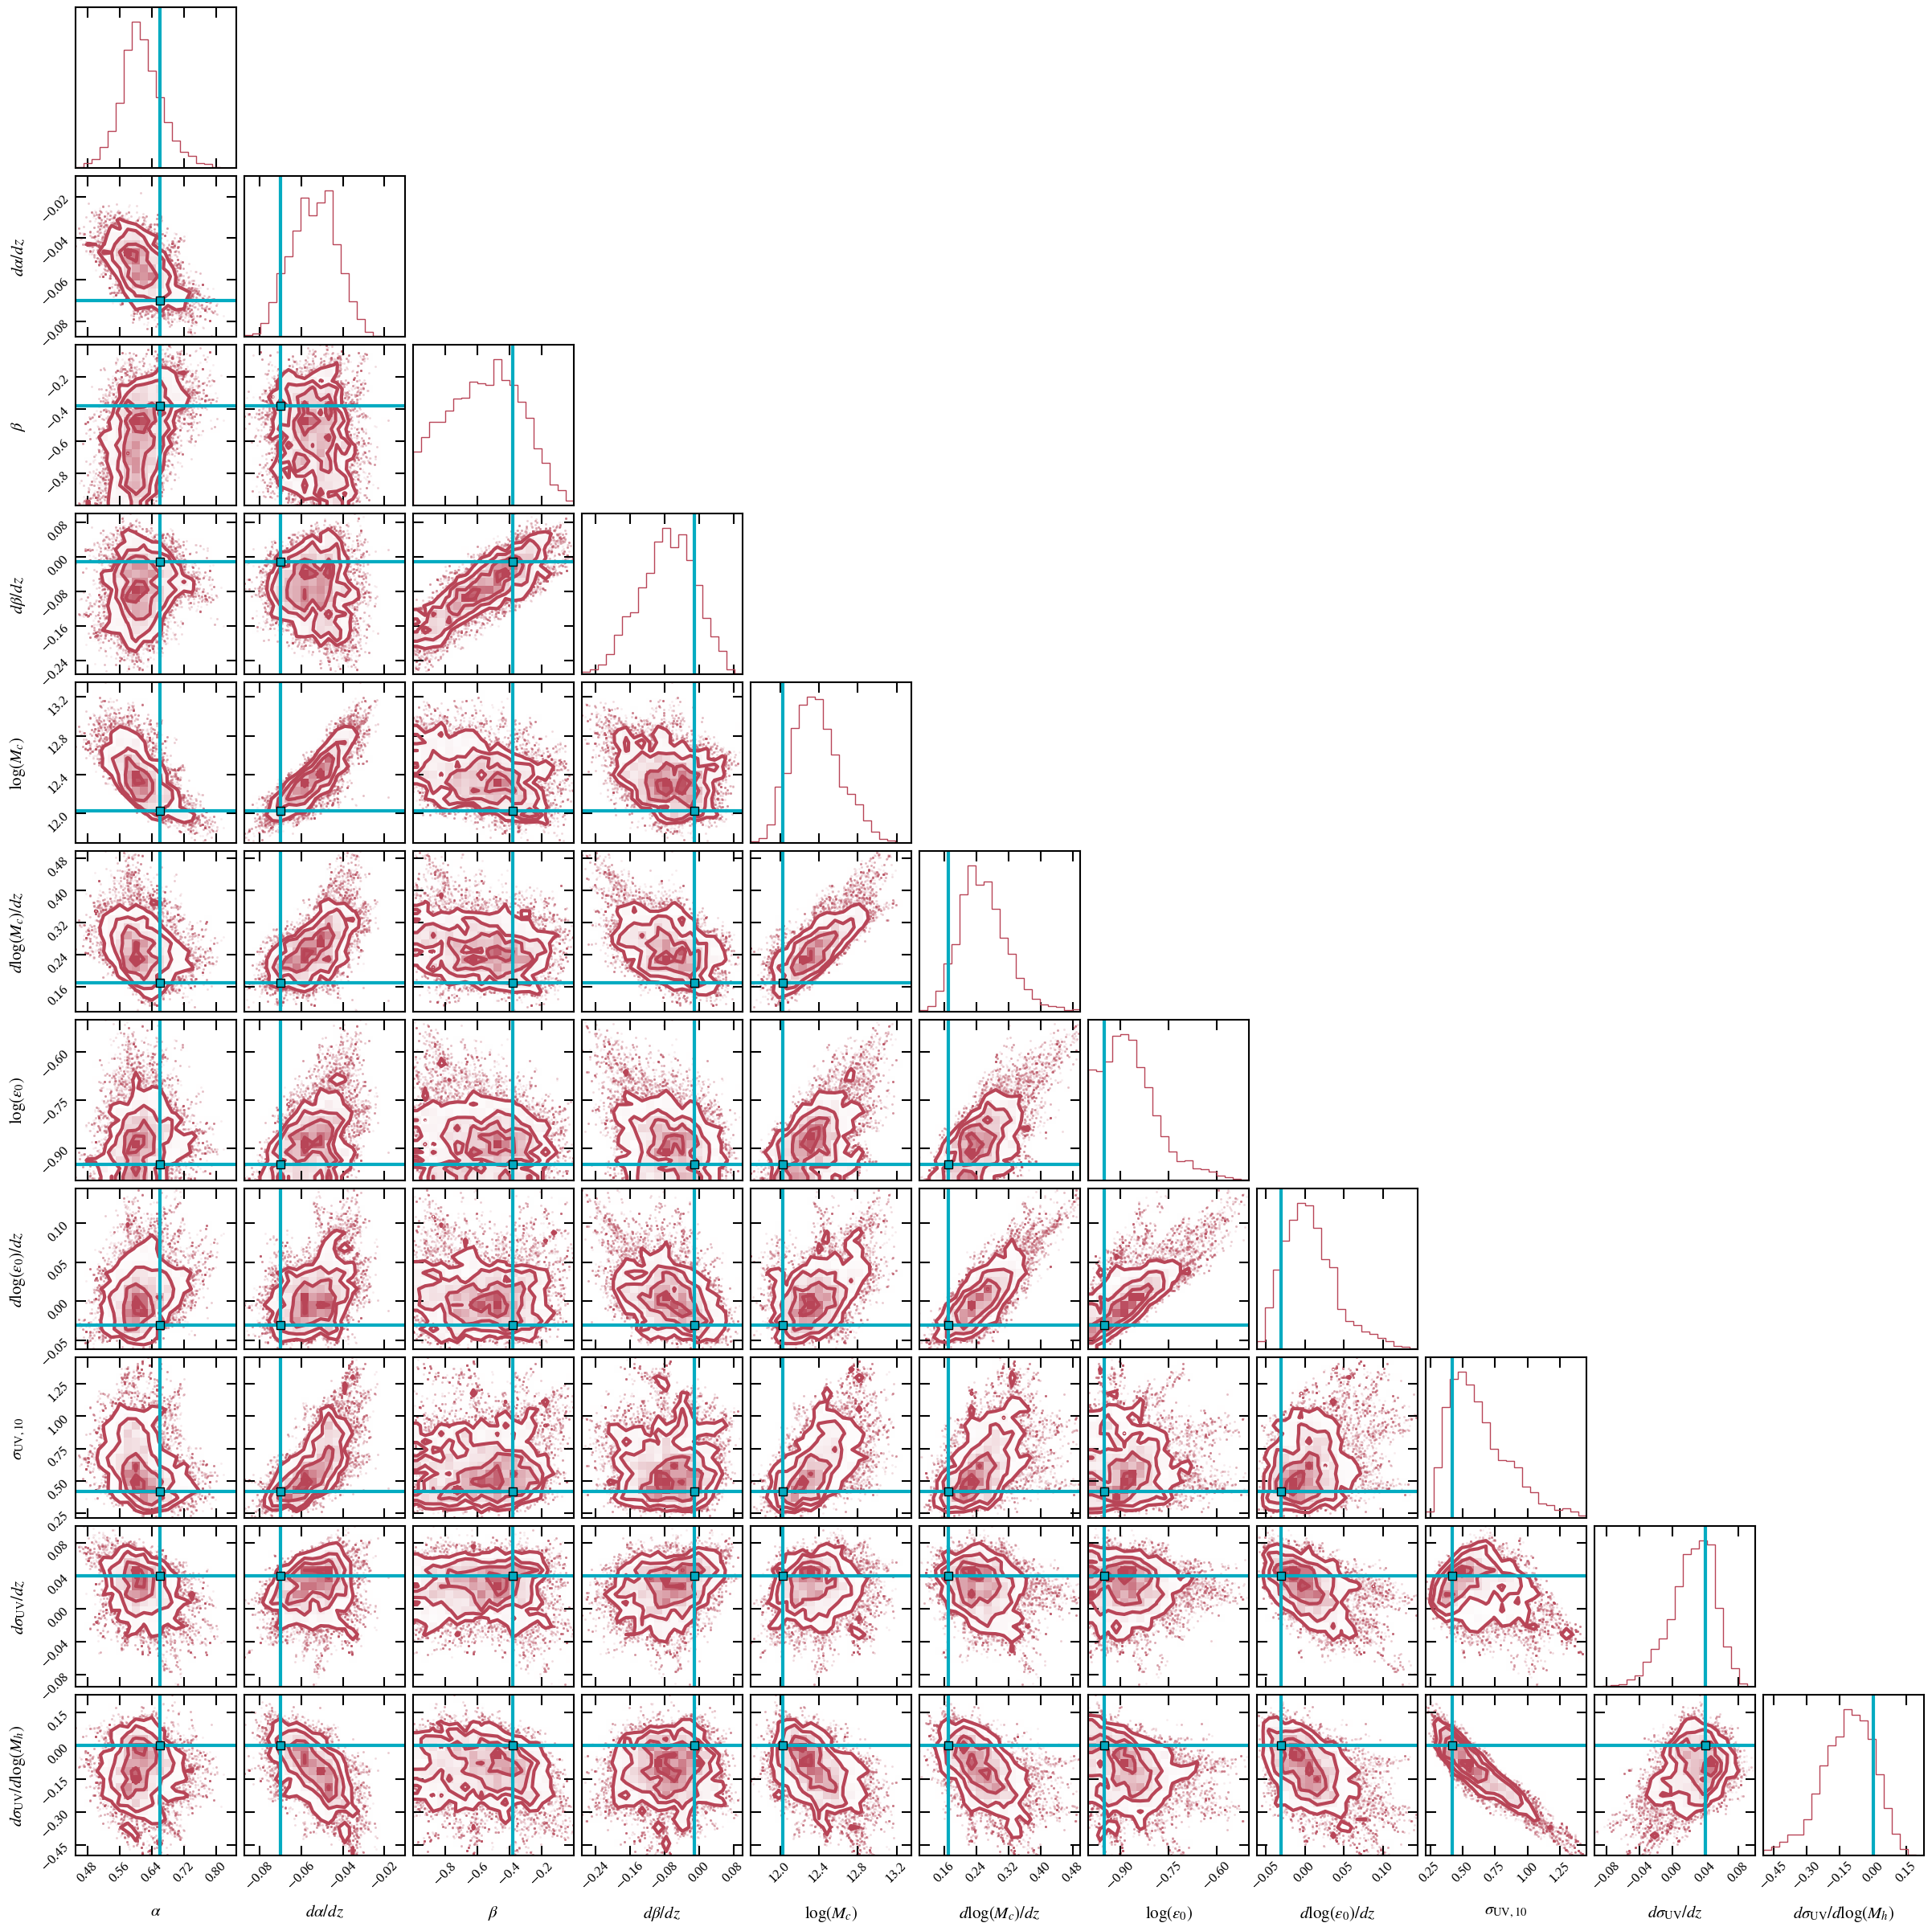

In [ ]:
corner_true = Plotting.plot_corner(samples, mock_UVLF, true_vals = true_params)

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


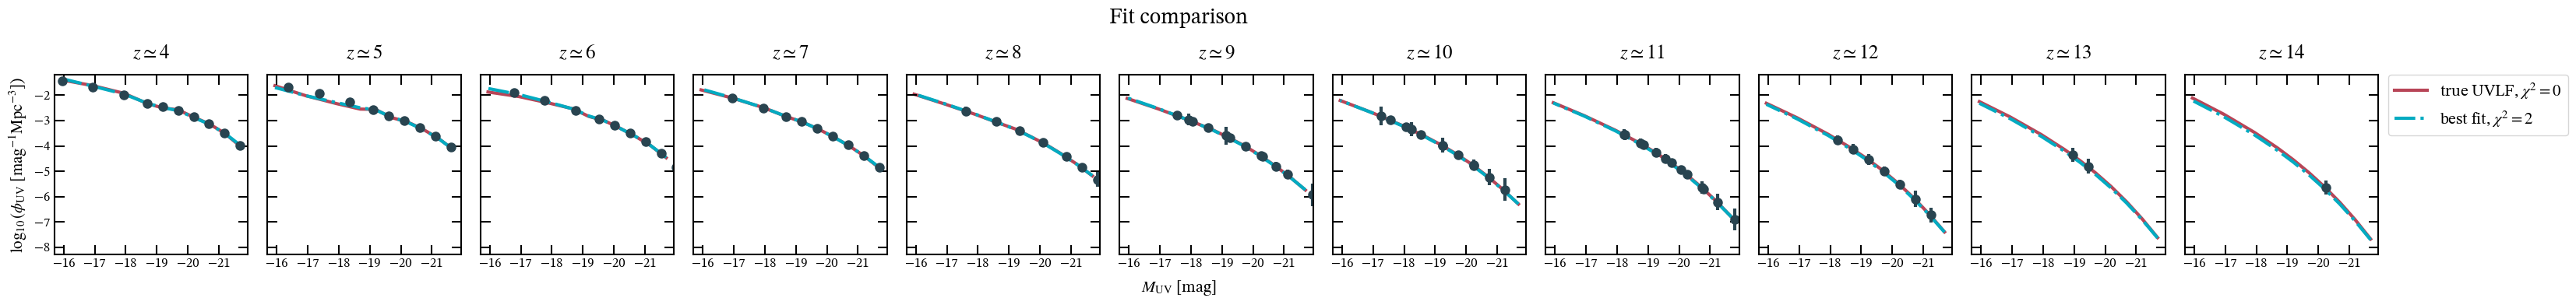

In [ ]:
comparison = Plotting.compare_fits(mock_files, data_labels = [''], best_fits = [true_params, best_fit], 
                                   fit_labels = ['true UVLF', 'best fit'])